# Notebook 16 — LLL basis reduction

Goal: understand what a "good basis" is, implement LLL from the definitions, and see it transform skewed bases into near-orthogonal ones. Pure Python.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pqc_edu.attacks_advanced.lll import gram_schmidt, lll_reduce

## Good vs bad bases

A basis is a set of generating vectors for a lattice. Two bases of the **same lattice** can look wildly different. A "good" basis has short, near-orthogonal vectors. A "bad" one has long, skewed vectors. LLL turns bad into good in polynomial time.

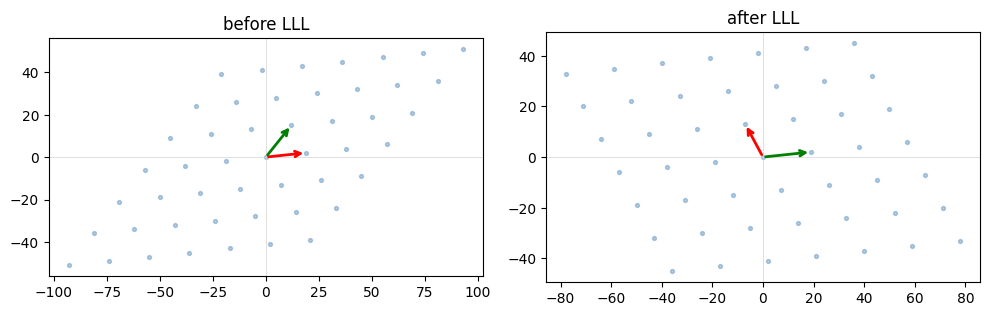

before: [[19, 2], [12, 15]]
after:  [[-7, 13], [19, 2]]


In [2]:
B = np.array([[19, 2], [12, 15]], dtype=np.int64)
R = lll_reduce(B, delta=0.99)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, basis, title in zip(axes, [B, R], ["before LLL", "after LLL"]):
    pts = []
    for i in range(-3, 4):
        for j in range(-3, 4):
            pts.append(i * basis[0] + j * basis[1])
    pts = np.array(pts)
    ax.scatter(pts[:, 0], pts[:, 1], s=8, color="steelblue", alpha=0.4)
    for v, c in zip(basis, ("red", "green")):
        ax.annotate("", xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2))
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axhline(0, color="lightgray", lw=0.5)
    ax.axvline(0, color="lightgray", lw=0.5)
plt.tight_layout(); plt.show()
print('before:', B.tolist())
print('after: ', R.tolist())

## Gram-Schmidt: the orthogonal skeleton

LLL works by tracking the Gram-Schmidt orthogonalization (GSO) of the basis. The GSO gives orthogonal vectors $b^*_i$ built by subtracting projections onto previous vectors.

In [3]:
B = np.array([[4, 1, 0], [2, 2, 0], [0, 1, 3]], dtype=np.int64)
B_star, mu = gram_schmidt(B)
print('B_star:'); print(B_star)
print('\northogonal?  (dot products)')
for i in range(3):
    for j in range(i+1, 3):
        print(f'  <b*{i}, b*{j}> = {np.dot(B_star[i], B_star[j]):.2e}')

B_star:
[[ 4.00000000e+00  1.00000000e+00  0.00000000e+00]
 [-3.52941176e-01  1.41176471e+00  0.00000000e+00]
 [ 8.32667268e-17  0.00000000e+00  3.00000000e+00]]

orthogonal?  (dot products)
  <b*0, b*1> = -4.44e-16
  <b*0, b*2> = 3.33e-16
  <b*1, b*2> = -2.94e-17


## The LLL conditions

A basis is LLL-reduced (with parameter $\delta \in (1/4, 1)$) iff

1. **Size-reduced**: $|\mu_{i,j}| \le 1/2$ for all $j < i$.
2. **Lovász**: $\|b^*_i\|^2 \ge (\delta - \mu_{i,i-1}^2)\|b^*_{i-1}\|^2$.

The first says each vector is "nearly orthogonal" to earlier ones. The second says consecutive GSO vectors don't shrink too fast.

## Hermite factor — measuring how good

Given a rank-$n$ lattice with determinant $\det(\Lambda)$, the shortest nonzero vector $\lambda_1$ satisfies (Minkowski bound) roughly $\|\lambda_1\| \le \sqrt{n} \cdot \det(\Lambda)^{1/n}$.

LLL's first vector satisfies $\|b_1\| \le \alpha^{(n-1)/2} \cdot \det(\Lambda)^{1/n}$ for $\alpha = 1/(\delta - 1/4)$. With $\delta = 0.99$, $\alpha \approx 1.35$. We measure the empirical **Hermite factor**: $\|b_1\| / \det(\Lambda)^{1/n}$.

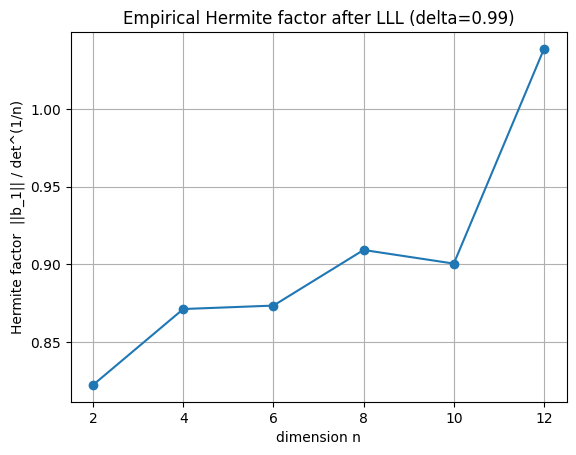

n= 2   Hermite factor = 0.822
n= 4   Hermite factor = 0.871
n= 6   Hermite factor = 0.874
n= 8   Hermite factor = 0.909
n=10   Hermite factor = 0.901
n=12   Hermite factor = 1.039


In [4]:
rng = np.random.default_rng(0)
dims = [2, 4, 6, 8, 10, 12]
factors = []
for n in dims:
    B = rng.integers(-50, 50, (n, n)).astype(np.int64)
    while abs(np.linalg.det(B)) < 1.0:
        B = rng.integers(-50, 50, (n, n)).astype(np.int64)
    R = lll_reduce(B, delta=0.99)
    det_n = abs(np.linalg.det(R.astype(float)))
    factors.append(np.linalg.norm(R[0]) / det_n ** (1.0 / n))
plt.plot(dims, factors, 'o-')
plt.xlabel('dimension n')
plt.ylabel('Hermite factor  ||b_1|| / det^(1/n)')
plt.title('Empirical Hermite factor after LLL (delta=0.99)')
plt.grid(True)
plt.show()
for n, f in zip(dims, factors):
    print(f'n={n:2d}   Hermite factor = {f:.3f}')

## What LLL is not

LLL gives an approximation guarantee, not exact SVP. The first vector can be up to $\alpha^{(n-1)/2}$ times longer than the true shortest vector. For attacking LWE we need shorter vectors than LLL alone delivers — enter BKZ.

→ `17_bkz_and_scaling.ipynb`